In [1]:
# libs
import pysam
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

plt.rcParams["figure.figsize"] = (4,4)

In [2]:
# path to ref
ref = "../references/combined_p2_c1_d1_ref_wo_primers.fasta"

# list of BAM files
tlbams = {
    "hp": "../data/trimmed_len_ont_mapped/camellia_21_filter_9_trimmed_ont_mapped.bam",
    "nj": "../data/trimmed_len_ont_mapped/camellia_22_filter_9_trimmed_ont_mapped.bam",
}

ubams = {
    "hp": "../data/camellia_21_no_filter.bam",
    "nj": "../data/camellia_22_no_filter.bam",
}

In [3]:
def tab_qc_bam(bam_dict, only_primary=False, check_sq=False):
    data = []
    for sample_name, bam_path in bam_dict.items():
        with pysam.AlignmentFile(bam_path, "rb", check_sq=check_sq) as bamfile:
            for read in bamfile:
                if only_primary and (read.is_unmapped or read.is_secondary or read.is_supplementary):
                    continue
                read_length = read.query_length
                if read_length is None:
                    qs = read.query_sequence
                    read_length = len(qs) if qs is not None else None
                data.append({
                    "name": sample_name,
                    "read_name": read.query_name,
                    "read_length": read_length,
                    "qs": read.get_tag("qs") if read.has_tag("qs") else None,
                    "st": read.get_tag("st") if read.has_tag("st") else None,
                })
    df = pd.DataFrame(data, columns=["name", "read_name", "read_length", "qs", "st"])
    return df


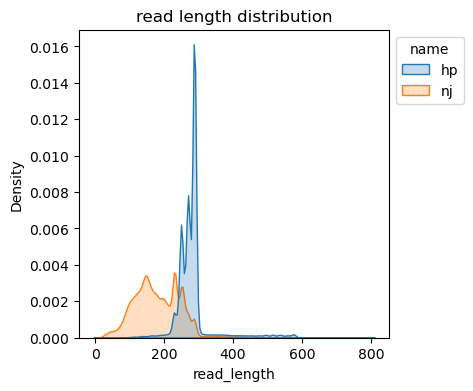

In [4]:
utb_qc = tab_qc_bam(
    bam_dict = ubams
)

utb_qc_len = utb_qc[(utb_qc["read_length"] <= 800)]

p1=sns.kdeplot(
    utb_qc_len,
    x = "read_length",
    hue = "name",
    fill=True
)
p1.set_title("read length distribution")
sns.move_legend(p1, "upper left", bbox_to_anchor=(1, 1))
plt.show()

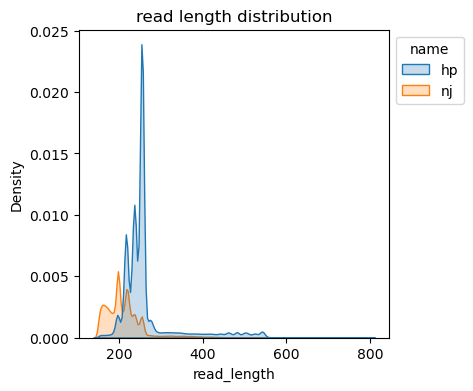

In [5]:
tltb_qc = tab_qc_bam(
    bam_dict = tlbams
)

tltb_qc_len = tltb_qc[(tltb_qc["read_length"] <= 800)]

p2=sns.kdeplot(
    tltb_qc_len,
    x = "read_length",
    hue = "name",
    fill=True
)
p2.set_title("read length distribution")
sns.move_legend(p2, "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [6]:
# count mapped reads
def count_primary_alignments_bam(bam_dict, ref):

    # get all ref ids
    fasta = pysam.FastaFile(ref)
    ref_ids = pd.DataFrame({"ref_id": fasta.references})
    fasta.close()

    data = []

    # iterate over bams
    for name, bam_file in bam_dict.items():
        bam = pysam.AlignmentFile(bam_file, "rb")
        
        for read in bam:
            if read.is_mapped and not read.is_secondary and not read.is_supplementary:
                
                ref_id = bam.get_reference_name(read.reference_id)
                width = read.reference_end - read.reference_start
                query_len = read.query_length # Length of the read sequence
                nm = read.get_tag("NM") if read.has_tag("NM") else None
                
                data.append((name, ref_id, width, nm, query_len))
        
        bam.close()
    
    df = pd.DataFrame(data, columns=["name", "ref_id", "width", "nm", "query_len"])

    grouped_df = (
        df.groupby(["name", "ref_id", "width", "nm", "query_len"])
        .size()
        .reset_index(name="count")
    )

    # cartesian of all bam names and reference IDs
    names = pd.DataFrame({"name": list(bam_dict.keys())})
    ref_cartesian = pd.merge(names, ref_ids, how="cross")

    res = pd.merge(
        ref_cartesian,
        grouped_df,
        on=["name", "ref_id"],
        how="left"
    )

    res["count"] = res["count"].fillna(0).astype(int)
    return res

In [7]:
res_trl = count_primary_alignments_bam(
    bam_dict = tlbams,
    ref = ref
)
res_trl.to_csv(
    "../results/rand_access_nj_trimmed_len_ont.csv.gz"
)

In [8]:
res_trl_summ = (
    res_trl
    .assign(
        pool=lambda df: df["ref_id"].str.split("_").str[0],
        length=lambda df: df["pool"].map({
            "p2": 140, 
            "c1": 140, 
            "d1": 207
        })
    )
    .loc[lambda df: 
        (abs(df["width"] - df["length"]) <= 3) & 
        (df["nm"] < 3)
    ]
    .groupby(["name", "pool"], as_index=False)
    .agg(n_mapped=("count", "sum"))
    .assign(
        total_per_name=lambda df: df.groupby("name")["n_mapped"].transform("sum"),        
        fraction=lambda df: df["n_mapped"] / df["total_per_name"],
        cpm=lambda df: df["fraction"] * 1e6
    )
)

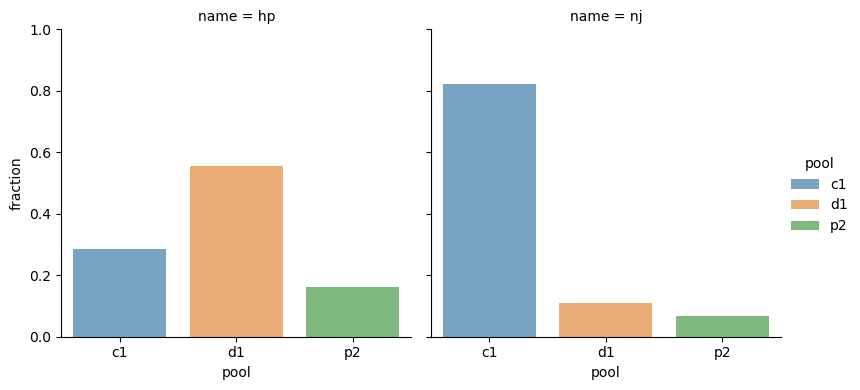

In [9]:
# plot fraction per prot
p3=sns.catplot(
    data=res_trl_summ,
    x="pool",
    y="fraction",
    hue="pool",
    col="name",
    kind="bar",
    alpha=0.65,
    dodge=False,
    height=4,
    aspect=1,
    legend=True
)

p3.set(ylim=(0, 1))
plt.show()

In [10]:
res_trl_ref = (
    res_trl
    .assign(
        pool=lambda df: df["ref_id"].str.split("_").str[0],
        length=lambda df: df["pool"].map({
            "p2": 140, 
            "c1": 140, 
            "d1": 207
        })
    )
    .loc[lambda df: 
        (abs(df["width"] - df["length"]) <= 3) & 
        (df["nm"] < 3)
    ]
    .groupby(["name", "pool", "ref_id"], as_index=False)
    .agg(n_mapped=("count", "sum"))
)

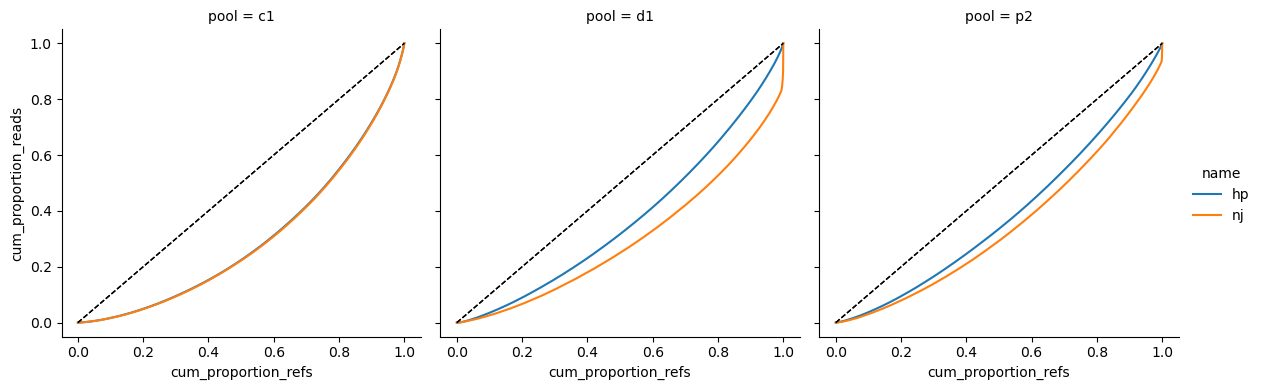

In [11]:
def lorenz_curve(arr):
    arr = np.array(sorted(arr))
    n = len(arr)
    
    if n == 0 or arr.sum() == 0:
        return np.array([0, 1]), np.array([0, 1])
        
    cum_ref = np.arange(1, n + 1) / n
    cum_val = np.cumsum(arr) / arr.sum()
    
    cum_ref = np.insert(cum_ref, 0, 0)
    cum_val = np.insert(cum_val, 0, 0)
    
    return cum_ref, cum_val

lorenz_data = []
for (name, pool), group_df in res_trl_ref.groupby(["name", "pool"]):
    data = group_df["n_mapped"].values
    
    cum_ref, cum_val = lorenz_curve(data)
    
    # append data points
    for i in range(len(cum_ref)):
        lorenz_data.append({
            "name": name,
            "pool": pool,
            "cum_proportion_refs": cum_ref[i],
            "cum_proportion_reads": cum_val[i]
        })

lorenz_df = pd.DataFrame(lorenz_data)

p4=sns.FacetGrid(
    data=lorenz_df, 
    col="pool", 
    hue="name",
    height=4,
    aspect=1,
)

p4.map_dataframe(
    sns.lineplot, 
    x="cum_proportion_refs", 
    y="cum_proportion_reads"
)

def plot_diagonal(*args, **kwargs):
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

p4.map(plot_diagonal)
p4.add_legend()
plt.show()